<a href="https://colab.research.google.com/github/taeyeon0102/gdgoc-archive/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# (1) 데이터 가져오기
!wget https://bit.ly/fruits_300_data -O fruits_300.npy
import numpy as np
fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

--2025-11-24 09:40:20--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2025-11-24 09:40:20--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2025-11-24 09:40:21--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... conne

In [ ]:
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):  #3차원 배열 매개변수
  n = len(arr)  #n개의 샘플
  rows = int(np.ceil(n/10)) #행 개수 계산
  cols = n if rows < 2 else 10  #열 개수 계산
  # 행이 1개이면 열의 개수는 샘플 개수/ 그렇지 않으면 10개
  fig, axs = plt.subplots(rows, cols, figsize=(cols*ratio, rows*ratio), squeeze=False)
  for i in range(rows):
    for j in range(cols):
      if i*10+j < n:  #n개 그림
        axs[i, j].imshow(arr[i*10+j], cmap='gray_r')
      axs[i, j].axis('off')

plt.show()

(50, 10000)


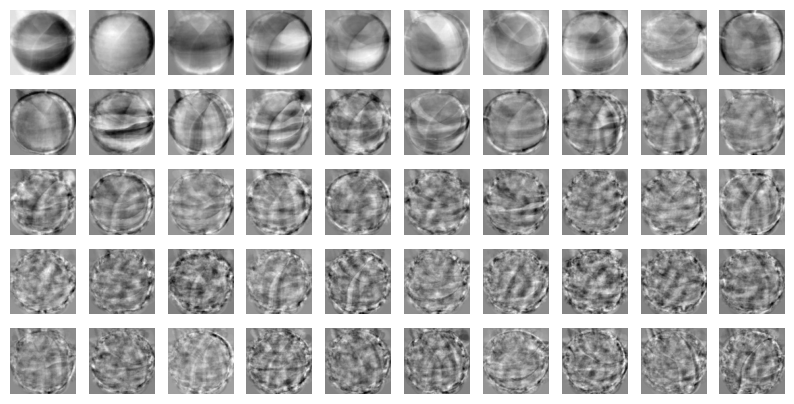

In [ ]:
# (2) 주성분 찾기
from sklearn.decomposition import PCA
pca = PCA(n_components = 50)
pca.fit(fruits_2d)

print(pca.components_.shape)  # 주성분의 크기 출력: 50개
draw_fruits(pca.components_.reshape(-1, 100, 100))    ##주성분 그리기 ->아까 만들었던 함수 이용

In [ ]:
# (3) 원본 데이터를 주성분에 투영(projection)
print(fruits_2d.shape)
fruits_pca = pca.transform(fruits_2d) # 투영하기(10000->50)
print(fruits_pca.shape)

(300, 10000)
(300, 50)


(300, 10000)








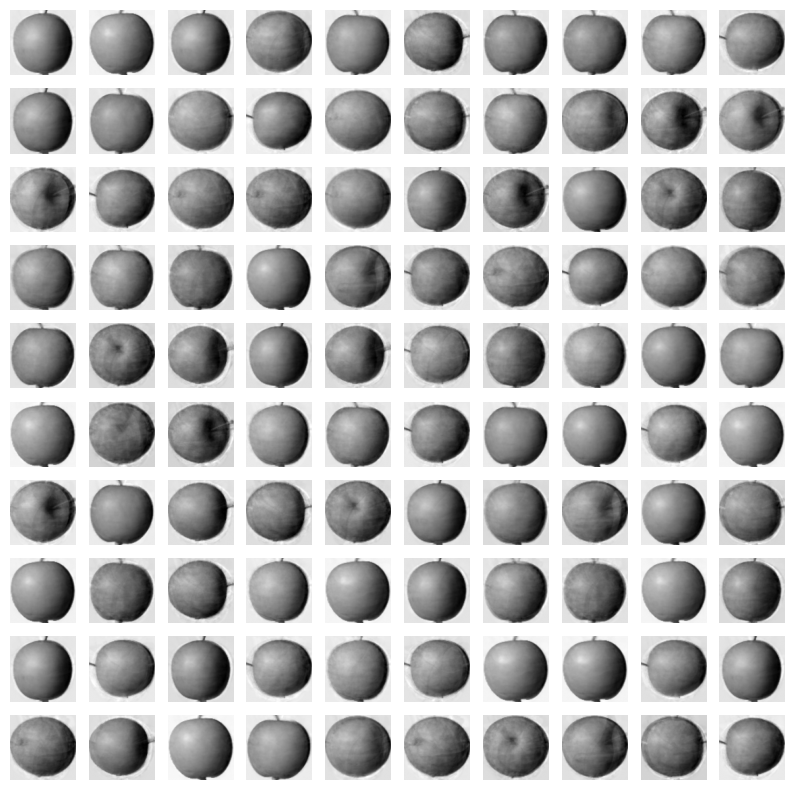

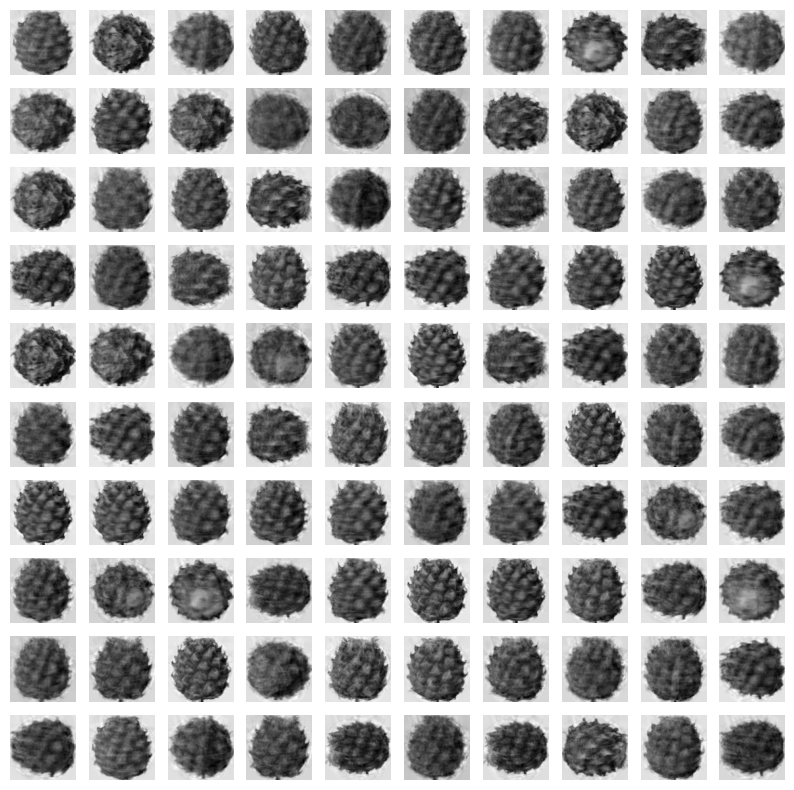

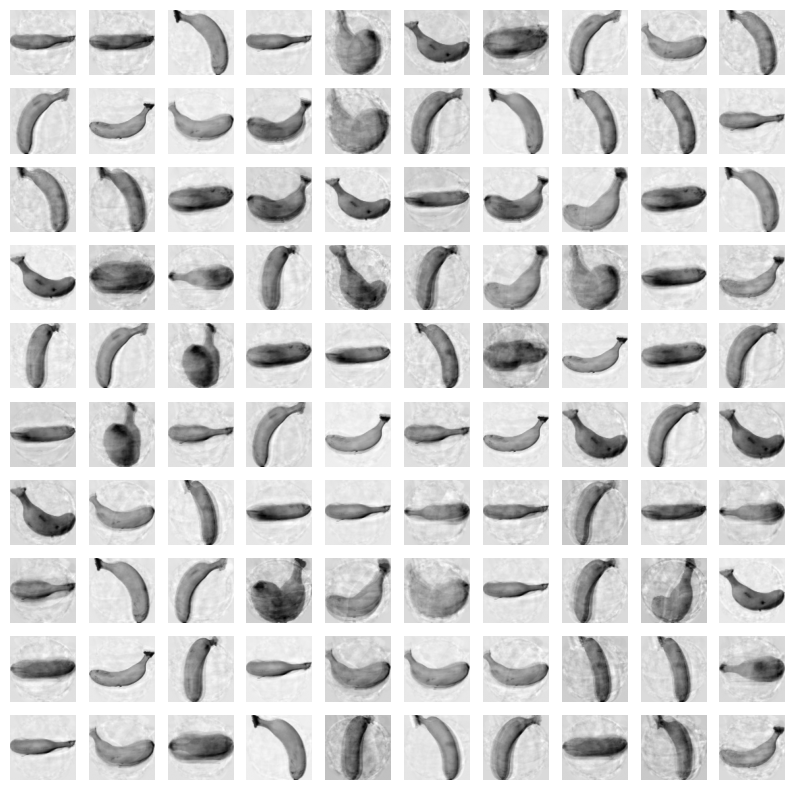

In [ ]:
# (4) 원본 데이터 복원
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)   ## 복원한 원본 그리기
for start in [0, 100, 200]:
  draw_fruits(fruits_reconstruct[start:start+100])
  print("\n")

0.9215806780113851


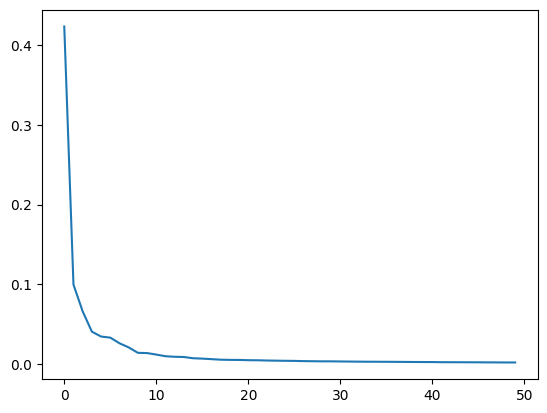

In [ ]:
#(5) 설명된 분산
print(np.sum(pca.explained_variance_ratio_))
plt.plot(pca.explained_variance_ratio_) ##그래프 그리기
plt.show()

In [ ]:
## 로지스틱 모델과 함께 사용
#(1) 로지스틱 회귀 모델 만들기
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
#(2) 타깃 만들기
target = np.array([0]*100 + [1]*100 + [2]*100)
#(3) 원본 데이터로 학습
from sklearn.model_selection import cross_validate
scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))
#(4) pca 데이터로 학습
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
1.285384178161621
0.9966666666666667
0.02787480354309082


In [ ]:
## (5) 설명된 분산의 50%에 달하는 주성분을 찾도록 pca 모델 만들기
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)
print(pca.n_components_)

2


In [ ]:
# (5-1) 2개 주성분으로 투영한 데이터로 학습
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape) ##투영한 데이터

scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

(300, 2)
0.99
0.0392669677734375


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
##(6) 차원 축소된 데이터로 k-평균 알고리즘으로 클러스터 찾기
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


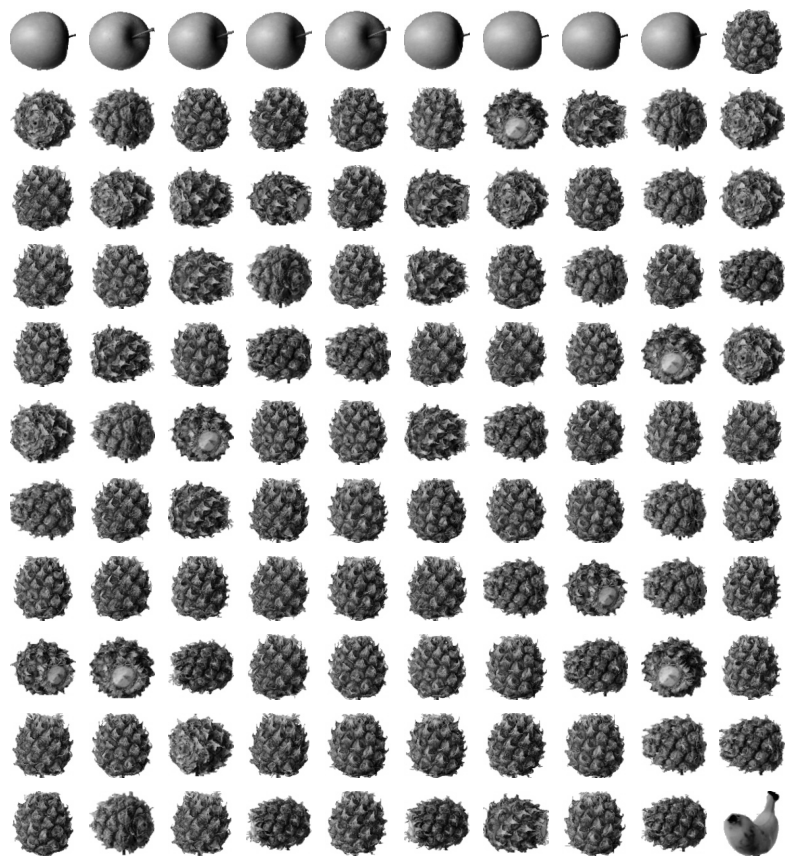

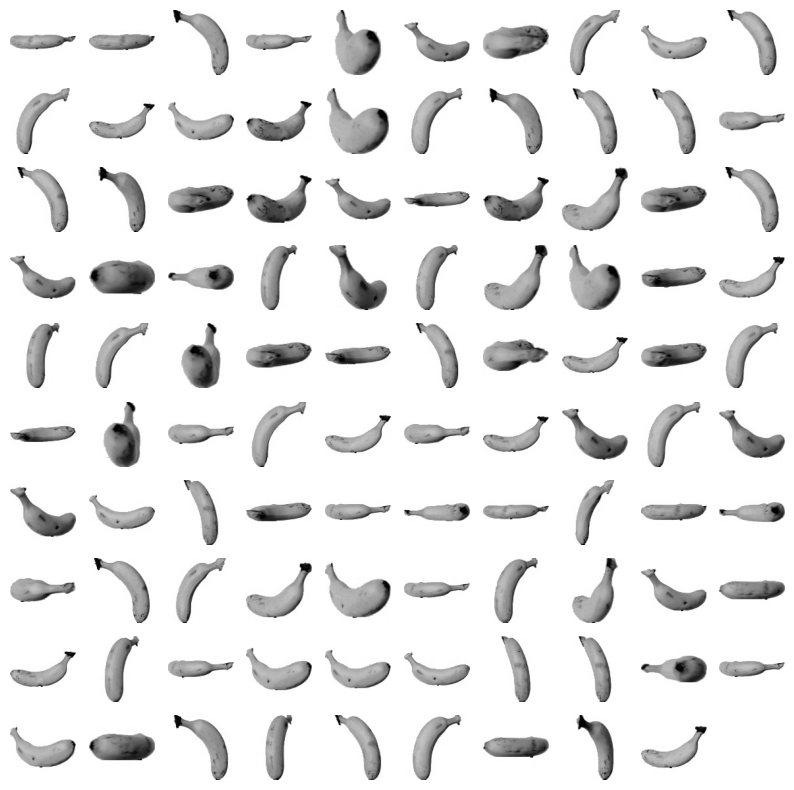

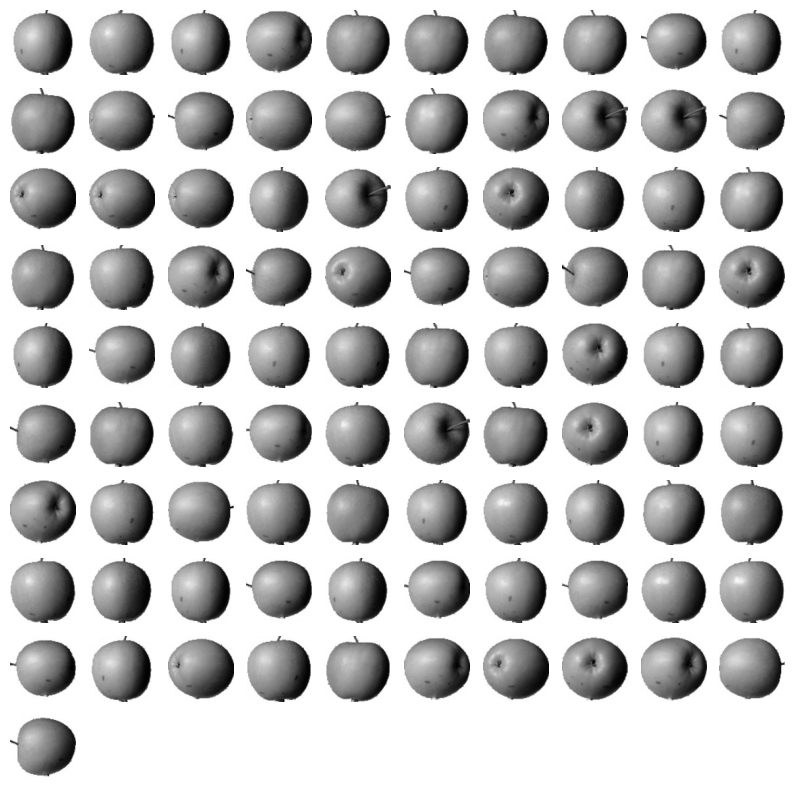

In [ ]:
#(6-1) 찾은 레이블을 사용해 과일 이미지 출력
for label in range(0, 3):
  draw_fruits(fruits[km.labels_ == label])
  print("\n")

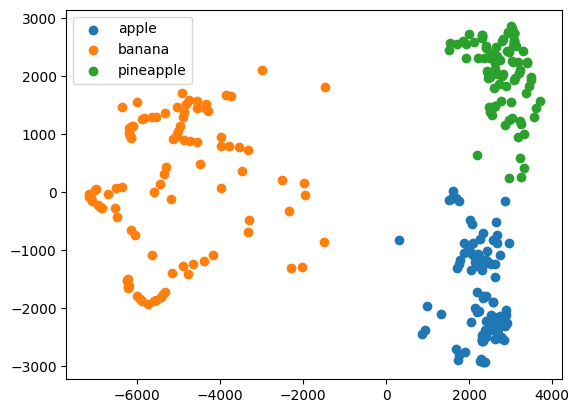

In [ ]:
#(6-2) 클러스터 별로 나누어 산점도 그리기
for label in range(0, 3):
  data = fruits_pca[km.labels_ == label]
  plt.scatter(data[:, 0], data[:, 1])
plt.legend(['apple', 'banana', 'pineapple'])
plt.show()